
## Submitted By

**Name:** Neha Chouhan  
**Course:** B.Tech (Artificial Intelligence)  
**Section:** B  
**Enrollment No.:** 24ADV3ARI0023

---

# Import Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save and Load Models
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
url = "https://raw.githubusercontent.com/shreyzo/Crop-yield-and-profitability-prediction/main/datafile.csv"

df_profit = pd.read_csv(url)

# EDA

In [3]:
df_profit.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare),Support price
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83,6000
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47,6000
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59,6000
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42,6000
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72,6000


In [4]:
df_profit.columns

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) ',
       'Support price'],
      dtype='object')

In [5]:
df_profit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     object 
 1   State                                  49 non-null     object 
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
 6   Support price                          49 non-null     int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 2.8+ KB


In [6]:
df_profit.isnull().sum()

Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
Support price                            0
dtype: int64

uniqe crops

In [7]:
print(df_profit["Crop"].unique())
print("Total Crops:", df_profit["Crop"].nunique())

['ARHAR' 'COTTON' 'GRAM' 'GROUNDNUT' 'MAIZE' 'MOONG' 'PADDY'
 'RAPESEED AND MUSTARD' 'SUGARCANE' 'WHEAT']
Total Crops: 10


Unique States

In [8]:
print(df_profit["State"].unique())
print("Total States:", df_profit["State"].nunique())

['Uttar Pradesh' 'Karnataka' 'Gujarat' 'Andhra Pradesh' 'Maharashtra'
 'Punjab' 'Haryana' 'Rajasthan' 'Madhya Pradesh' 'Tamil Nadu' 'Bihar'
 'Orissa' 'West Bengal']
Total States: 13


Rename long columns names

In [ ]:
df_profit = df_profit.rename(columns={
    "Cost of Cultivation (`/Hectare) A2+FL": "Cost_Cultivation_A2FL",
    "Cost of Cultivation (`/Hectare) C2": "Cost_Cultivation_C2",
    "Cost of Production (`/Quintal) C2": "Cost_Production_C2",
    "Yield (Quintal/ Hectare) ": "Yield_Quintal_Hectare",
    "Support price": "Support_Price"
})

In [10]:
df_profit.columns

Index(['Crop', 'State', 'Cost_Cultivation_A2FL', 'Cost_Cultivation_C2',
       'Cost_Production_C2', 'Yield_Quintal_Hectare', 'Support_Price'],
      dtype='object')

Compute Profitability

In [11]:
# Revenue per Hectare

df_profit["Revenue_per_Hectare"] = (
    df_profit["Support_Price"] *
    df_profit["Yield_Quintal_Hectare"]
)

In [12]:
# Profit per Hectare

df_profit["Profit_per_Hectare"] = (
    df_profit["Revenue_per_Hectare"] -
    df_profit["Cost_Cultivation_C2"]
)

In [13]:
df_profit.head()

,Crop,State,Cost_Cultivation_A2FL,Cost_Cultivation_C2,Cost_Production_C2,Yield_Quintal_Hectare,Support_Price,Revenue_per_Hectare,Profit_per_Hectare
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83,6000,58980.0,35903.26
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47,6000,44820.0,28291.32
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59,6000,57540.0,37988.10
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42,6000,38520.0,14348.35
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72,6000,52320.0,27049.74


Rank Crops by Average Profitability

In [14]:
avg_profit = (
    df_profit.groupby("Crop")["Profit_per_Hectare"]
      .mean()
      .reset_index()
)

groupby("Crop")

Because the same crop appears in multiple states. We want one average profit value for each crop.

In [15]:
# Sort from Highest to Lowest

avg_profit = avg_profit.sort_values(
    by="Profit_per_Hectare",
    ascending=False
)

avg_profit

,Crop,Profit_per_Hectare
8,SUGARCANE,145636.3340
1,COTTON,60569.3820
6,PADDY,50712.7060
7,RAPESEED AND MUSTARD,45364.5680
9,WHEAT,37029.4175
2,GRAM,34537.0260
4,MAIZE,33139.0020
0,ARHAR,28716.1540
3,GROUNDNUT,26081.1240
5,MOONG,19418.0200


Plot Horizontal Bar Chart

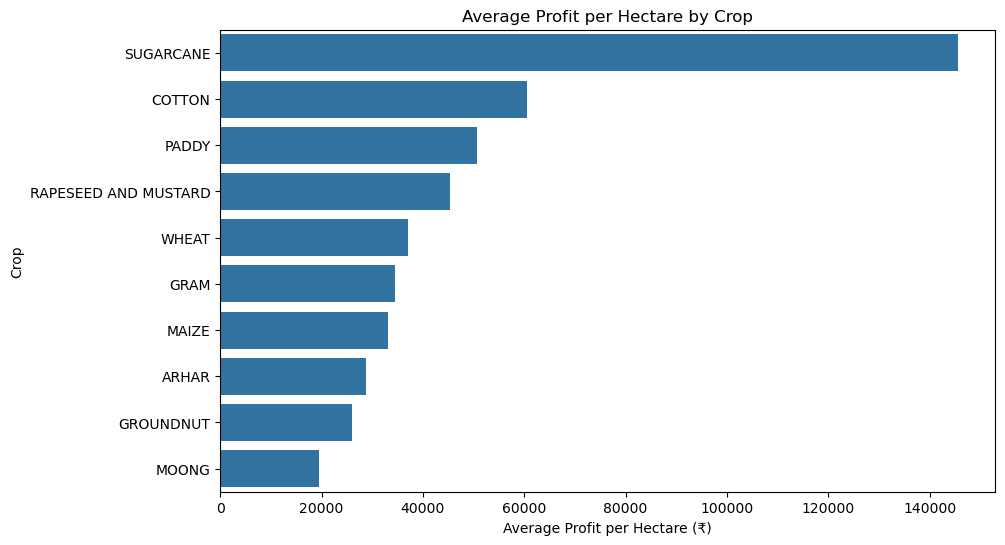

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_profit,
    x="Profit_per_Hectare",
    y="Crop"
)

plt.title("Average Profit per Hectare by Crop")
plt.xlabel("Average Profit per Hectare (₹)")
plt.ylabel("Crop")

plt.show()

# LinearRegression

In [17]:
X = df_profit[
    [
        "Cost_Cultivation_A2FL",
        "Cost_Cultivation_C2",
        "Yield_Quintal_Hectare"
    ]
]

y = df_profit["Cost_Production_C2"]

In [18]:
lr_model = LinearRegression()

lr_model.fit(X, y)

LinearRegression()

In [19]:
y_pred = lr_model.predict(X)

In [20]:
r2 = r2_score(y, y_pred)

print("Training R² Score:", r2)

Training R² Score: 0.3469293725224437


 We didn't split the data into training and testing because the dataset contains only 49 rows. Therefore, the R² score is only a rough estimate and not a true measure of how well the model will perform on new, unseen data.

get_profit_estimate() Function

In [21]:
def get_profit_estimate(crop, state):
    # Convert crop name to uppercase
    crop = crop.upper()

    # Filter matching row
    result = df_profit[
        (df_profit["Crop"] == crop) &
        (df_profit["State"] == state)
    ]

    # If no matching row
    if result.empty:
        return None

    # Get first matching row
    row = result.iloc[0]

    # Return required information
    return {
        "Crop": row["Crop"],
        "State": row["State"],
        "Support Price": row["Support_Price"],
        "Cost of Cultivation (C2)": row["Cost_Cultivation_C2"],
        "Historical Yield": row["Yield_Quintal_Hectare"],
        "Profit per Hectare": row["Profit_per_Hectare"]
    }

In [22]:
# test

get_profit_estimate("wheat", "Punjab")

{'Crop': 'WHEAT',
 'State': 'Punjab',
 'Support Price': np.int64(1975),
 'Cost of Cultivation (C2)': np.float64(35423.48),
 'Historical Yield': np.float64(39.83),
 'Profit per Hectare': np.float64(43240.77)}

# Conclusion

Successfully loaded the government crop cost and support price dataset.

Renamed lengthy column names into shorter and more meaningful names for easier analysis.
Calculated Revenue per Hectare using Support Price and Yield values.
Calculated Profit per Hectare by subtracting Cost of Cultivation from Revenue.
Ranked crops according to their average profitability across different states.

Visualized profitability using a horizontal bar chart for easy comparison.

Trained a Linear Regression model to estimate Cost of Production based on cultivation costs and yield.
Evaluated the model using the training R² Score and documented its limitations due to the small dataset size.
Developed a reusable get_profit_estimate() function to retrieve historical profitability information for existing crop-state combinations.

The module successfully provides profitability analysis and completes the economic assessment stage of the Smart Crop Advisory System.